<a href="https://colab.research.google.com/github/toryor31oct/group15-Fun-Rai-Kwam-plod-Phai/blob/Film/fun_rai_kwam_plod_phai_ipynb(graph1)_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# โหลดไฟล์ข้อมูลการเคลม

In [4]:
import pandas as pd

# (มีข้อมูลลูกค้าและกรมธรรม์อยู่แล้ว)
df_claims = pd.read_csv("claims_system.csv")

# ตั้งค่าฟอร์แมตตัวเลข
pd.options.display.float_format = "{:,.2f}".format


In [5]:
import pandas as pd
import numpy as np
import os, shutil
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

In [6]:
# 1. ติดตั้งฟอนต์ภาษาไทย
!apt-get -y install fonts-thai-tlwg

# 2. ล้าง cache ของ matplotlib เพื่ออัปเดตฟอนต์ใหม่
cache_dir = matplotlib.get_cachedir()
if os.path.exists(cache_dir):
    shutil.rmtree(cache_dir)

# 3. ลงทะเบียนฟอนต์ใหม่เข้ากับ FontManager
font_path = '/usr/share/fonts/truetype/tlwg/Loma.ttf'
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)

# 4. ตั้งค่าฟอนต์หลัก
plt.rcParams['font.family'] = 'Loma'
plt.rcParams['axes.unicode_minus'] = False

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  fonts-tlwg-garuda fonts-tlwg-garuda-ttf fonts-tlwg-kinnari
  fonts-tlwg-kinnari-ttf fonts-tlwg-laksaman fonts-tlwg-laksaman-ttf
  fonts-tlwg-loma fonts-tlwg-loma-ttf fonts-tlwg-mono fonts-tlwg-mono-ttf
  fonts-tlwg-norasi fonts-tlwg-norasi-ttf fonts-tlwg-purisa
  fonts-tlwg-purisa-ttf fonts-tlwg-sawasdee fonts-tlwg-sawasdee-ttf
  fonts-tlwg-typewriter fonts-tlwg-typewriter-ttf fonts-tlwg-typist
  fonts-tlwg-typist-ttf fonts-tlwg-typo fonts-tlwg-typo-ttf fonts-tlwg-umpush
  fonts-tlwg-umpush-ttf fonts-tlwg-waree fonts-tlwg-waree-ttf
The following NEW packages will be installed:
  fonts-thai-tlwg fonts-tlwg-garuda fonts-tlwg-garuda-ttf fonts-tlwg-kinnari
  fonts-tlwg-kinnari-ttf fonts-tlwg-laksaman fonts-tlwg-laksaman-ttf
  fonts-tlwg-loma fonts-tlwg-loma-ttf fonts-tlwg-mono fonts-tlwg-mono-ttf
  fonts-tlwg-norasi fonts-tlwg-norasi-ttf fo

# ตั้งคำถามเกี่ยวกับธุรกิจแล้วตอบด้วย pandas
คำถามที่ 1: ประกันแต่ละประเภทมี "ยอดรวมเงินจ่ายสุทธิ" และ "ยอดขอเบิกเฉลี่ย" เท่าใด

คำถามที่ 2: ภาพรวมสถานะการอนุมัติ (Approved vs Rejected) มีจำนวนกี่เคส และจ่ายเงินสุทธิรวมเท่าใด

คำถามที่ 3: เมื่อจำแนกตามประเภทประกัน มีจำนวนเคสที่ผ่านอนุมัติและถูกปฏิเสธอย่างไรบ้าง?

คำถามที่ 4: ผู้รับประโยชน์กลุ่มไหน (บิดา, มารดา, บุตร ฯลฯ) มีจำนวนเคสมากสุด พร้อมยอดจ่ายสูงสุดและค่าเฉลี่ย?

In [7]:
# คำถามที่ 1: ประกันแต่ละประเภทมี "ยอดรวมเงินจ่ายสุทธิ" และ "ยอดขอเบิกเฉลี่ย" เท่าใด

q1_df = (df_claims.groupby("insurance_type").agg(
        total_net_payout = ("net_payout", "sum"),
        avg_claim_amount = ("claim_amount", "mean"),).sort_values(by="total_net_payout", ascending=False))
display(q1_df)

,total_net_payout,avg_claim_amount
insurance_type,,
ประกันชีวิต,"137,857,500.00","1,071,699.13"
ประกันโรคร้ายแรง,"81,972,000.00","664,804.59"
ประกันสุขภาพ,"26,216,579.78","469,881.22"
ประกันอุบัติเหตุ,"19,886,779.63","325,320.82"


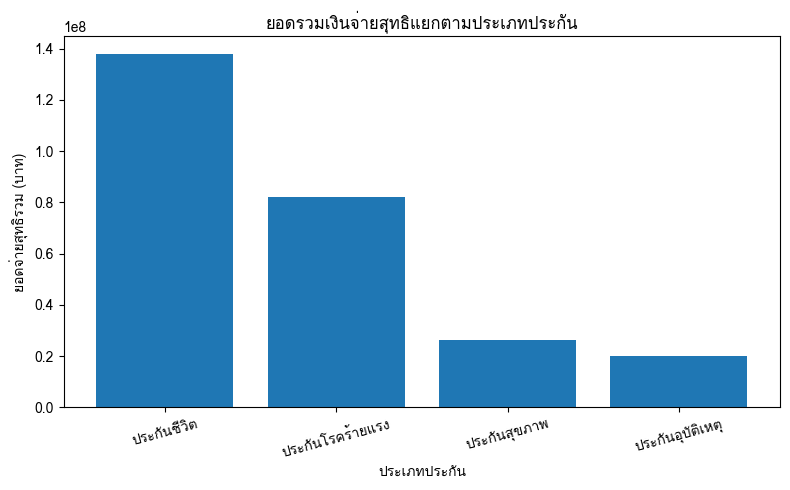

In [12]:
plt.figure(figsize=(8, 5))

plt.bar(q1_df.index, q1_df["total_net_payout"])

plt.title("ยอดรวมเงินจ่ายสุทธิแยกตามประเภทประกัน")
plt.xlabel("ประเภทประกัน")
plt.ylabel("ยอดจ่ายสุทธิรวม (บาท)")
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

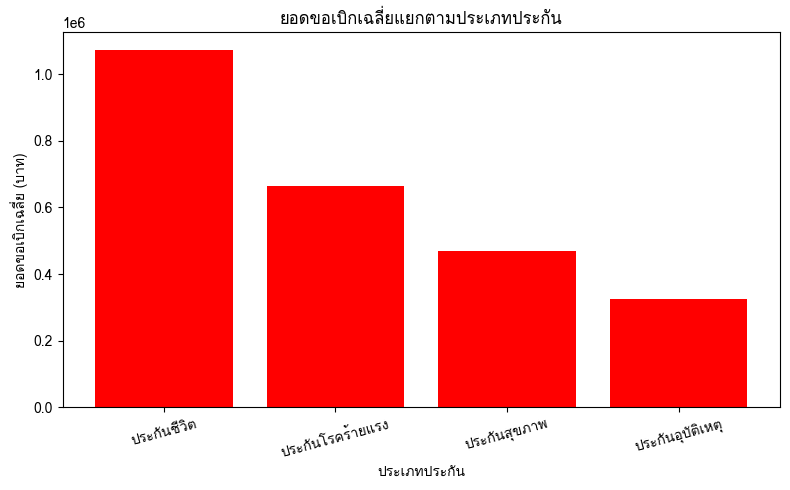

In [14]:
plt.figure(figsize=(8, 5))

plt.bar(q1_df.index, q1_df["avg_claim_amount"], color="red")

plt.title("ยอดขอเบิกเฉลี่ยแยกตามประเภทประกัน")
plt.xlabel("ประเภทประกัน")
plt.ylabel("ยอดขอเบิกเฉลี่ย (บาท)")
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

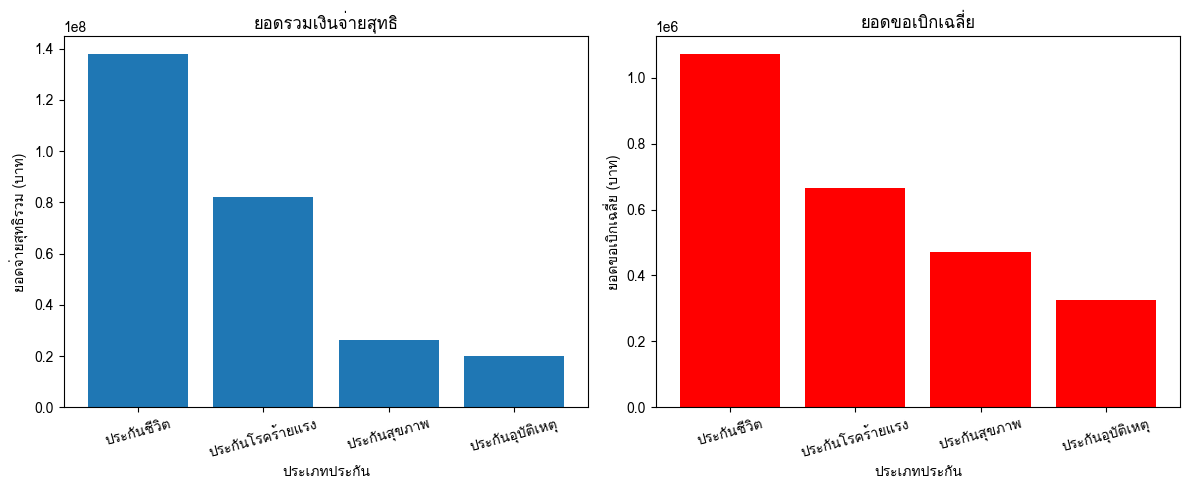

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# กราฟที่ 1: ยอดรวมเงินจ่ายสุทธิ
axes[0].bar(q1_df.index, q1_df["total_net_payout"])
axes[0].set_title("ยอดรวมเงินจ่ายสุทธิ")
axes[0].set_xlabel("ประเภทประกัน")
axes[0].set_ylabel("ยอดจ่ายสุทธิรวม (บาท)")
axes[0].tick_params(axis="x", rotation=15)

# กราฟที่ 2: ยอดขอเบิกเฉลี่ย
axes[1].bar(q1_df.index, q1_df["avg_claim_amount"], color="red")
axes[1].set_title("ยอดขอเบิกเฉลี่ย")
axes[1].set_xlabel("ประเภทประกัน")
axes[1].set_ylabel("ยอดขอเบิกเฉลี่ย (บาท)")
axes[1].tick_params(axis="x", rotation=15)


plt.tight_layout()
plt.show()